In [1]:
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from hierarchical_clustering_invariant import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import pandas as pd
import seaborn as sns
from pygam import LogisticGAM, s
import matplotlib.cm as cm

## p-value validity

In [48]:
df = pd.read_csv("/Users/judydw/Downloads/pval_data_randomized.csv")
df2 = pd.read_csv("/Users/judydw/Downloads/pval_data.csv")

In [49]:
df2

,Gao (sigma_all),Gao (sigma_clustered),Barber
0,0.260149,0.902191,0.466496
1,0.733602,0.763158,0.566399
2,0.947733,0.424244,0.082415
3,0.942243,0.306644,0.869914
4,0.066121,0.503419,0.517534
...,...,...,...
495,0.468335,0.642727,0.277655
496,0.661701,0.960679,0.795614
497,0.649746,0.903227,0.111217
498,0.385134,0.921541,0.955213


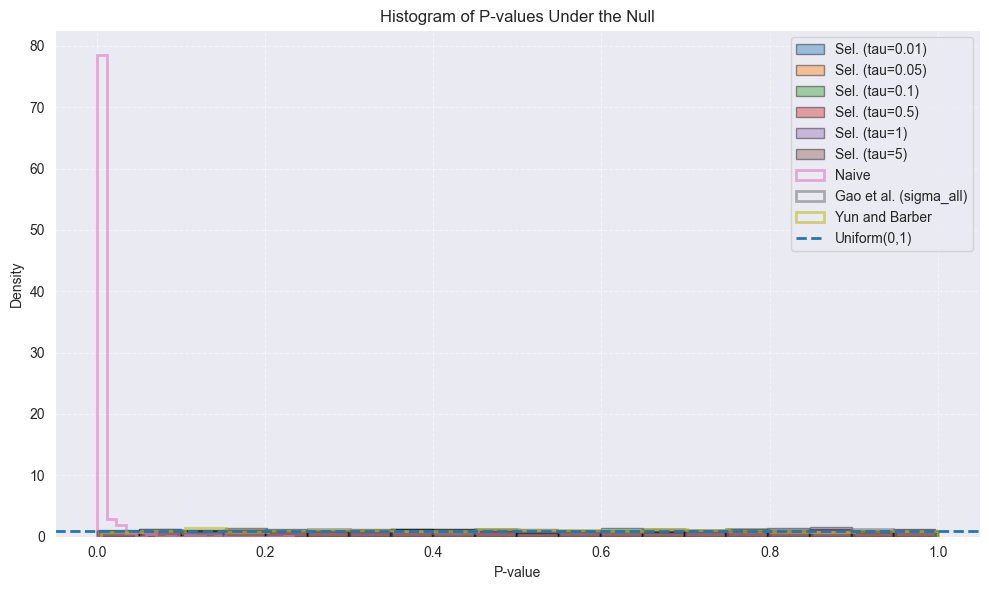

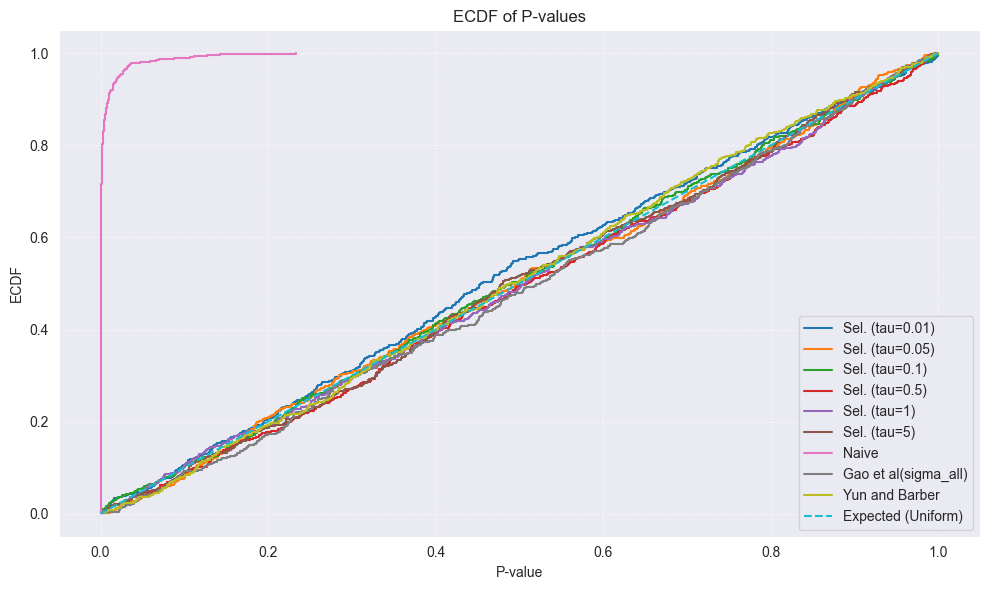

ValueError: x and y must have same first dimension, but have shapes (499,) and (500,)

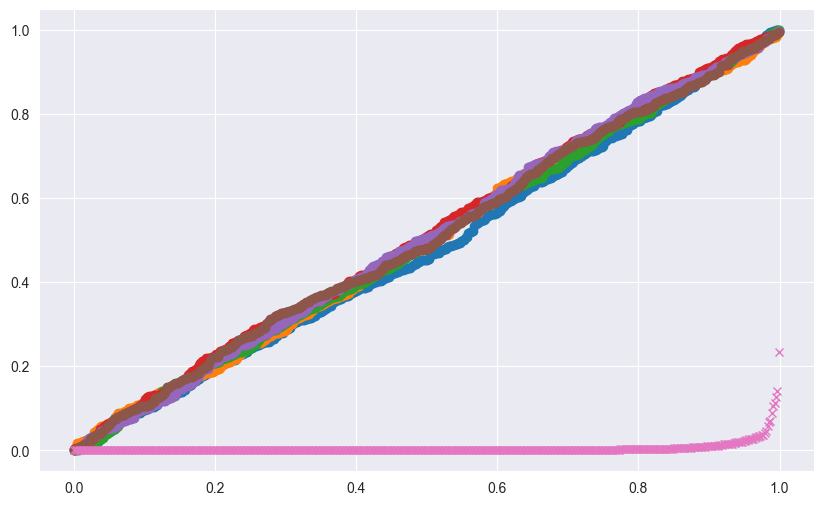

In [51]:
tau_cols = [c for c in df.columns if c.startswith('tau=')]
naive = df['naive'].dropna().to_numpy()
gao = df2['Gao (sigma_all)']
#gao_c = df2['Gao (sigma_clustered)']
barber = df2['Barber']
# ---------- 1) 直方图 ----------
plt.figure(figsize=(10, 6))
for col in tau_cols:
    vals = df[col].dropna().to_numpy()
    plt.hist(vals, bins=20, density=True, alpha=0.4, edgecolor='black',
             label=f"Sel. ({col})")
plt.hist(naive, bins=20, density=True, alpha=0.6, histtype='step', linewidth=2,
         label="Naive")
plt.hist(gao, bins=20, density=True, alpha=0.6, histtype='step', linewidth=2,
         label="Gao et al. (sigma_all)")
#plt.hist(gao_c, bins=20, density=True, alpha=0.6, histtype='step', linewidth=2,
#         label="Gao et al. (sigma_clustered)")
plt.hist(barber, bins=20, density=True, alpha=0.6, histtype='step', linewidth=2,
         label="Yun and Barber")
plt.axhline(1, linestyle='--', linewidth=2, label="Uniform(0,1)")
plt.xlabel("P-value"); plt.ylabel("Density")
plt.title("Histogram of P-values Under the Null")
plt.legend(); plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout(); plt.show()

# ---------- 2) ECDF ----------
def plot_ecdf(values, label):
    x = np.sort(values)
    y = np.arange(1, len(x) + 1) / len(x)
    plt.step(x, y, where='post', label=label)

plt.figure(figsize=(10, 6))
for col in tau_cols:
    plot_ecdf(df[col].dropna().to_numpy(), f"Sel. ({col})")
plot_ecdf(naive, "Naive")
plot_ecdf(gao, "Gao et al(sigma_all)")
#plot_ecdf(gao_c, "Gao et al(sigma_clustered)")
plot_ecdf(barber, "Yun and Barber")
plt.plot([0, 1], [0, 1], linestyle="--", label="Expected (Uniform)")
plt.xlabel("P-value"); plt.ylabel("ECDF")
plt.title("ECDF of P-values")
plt.legend(); plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout(); plt.show()

plt.figure(figsize=(10, 6))
for col in tau_cols:
    vals = np.sort(df[col].dropna().to_numpy())
    n = len(vals)
    theo = (np.arange(1, n + 1) - 0.5) / n
    plt.plot(theo, vals, marker='o', linestyle='', label=f"Sel. ({col})")
vals_naive = np.sort(naive)
vals_barber = np.sort(barber)
vals_gao = np.sort(gao)
#vals_gao_c = np.sort(gao_c)
n0 = len(vals_naive)
theo0 = (np.arange(1, n0 + 1) - 0.5) / n0
plt.plot(theo0, vals_naive, marker='x', linestyle='', label="Naive")
plt.plot(theo0, vals_barber, marker='x', linestyle='', label="Yun and Barber")
plt.plot(theo0, vals_gao, marker='x', linestyle='', label="Gao et al. (sigma_all)")
#plt.plot(theo0, vals_gao_c, marker='x', linestyle='', label="Gao et al.(sigma_clustered)")
plt.plot([0, 1], [0, 1], linestyle="--", label="Expected (Uniform)")
plt.xlabel("Theoretical Uniform Quantiles")
plt.ylabel("Empirical P-values")
plt.title("Q-Q Plot: P-values vs. Uniform(0,1)")
plt.legend(); plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout(); plt.show()

# Type I error

In [32]:
type1_gao = pd.read_csv("/Users/judydw/Downloads/type1_gao_by_repeat-2.csv")
type1_gao_c = pd.read_csv("/Users/judydw/Downloads/type1_gao_c_by_repeat.csv")
type1_barber = pd.read_csv("/Users/judydw/Downloads/type1_barber_by_repeat-2.csv")
type1 = pd.read_csv("/Users/judydw/Downloads/type1_error_results.csv")
alpha = 0.05

In [33]:
type1_gao_c

,Method,Label,Type I Error
0,Gao,Gao (sigma_clustered),0.090
1,Gao,Gao (sigma_clustered),0.075
2,Gao,Gao (sigma_clustered),0.085
3,Gao,Gao (sigma_clustered),0.105
4,Gao,Gao (sigma_clustered),0.080
...,...,...,...
95,Gao,Gao (sigma_clustered),0.065
96,Gao,Gao (sigma_clustered),0.060
97,Gao,Gao (sigma_clustered),0.095
98,Gao,Gao (sigma_clustered),0.100


/var/folders/p_/wj4jvr5929x__hfp1fb3gy400000gs/T/ipykernel_23939/3760704520.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=order, showfliers=False, patch_artist=True)


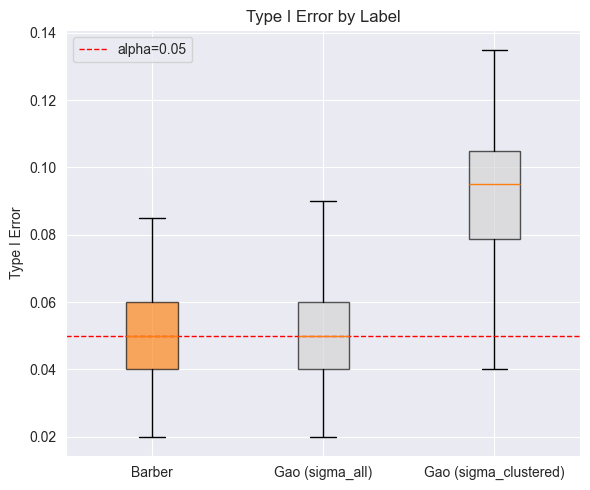

In [34]:
df = pd.concat([type1_gao,type1_gao_c, type1_barber], ignore_index=True)
df = df.dropna(subset=['Type I Error', 'Label'])

order = ['Gao','Barber'] if {'Gao','Barber'}.issubset(set(df['Label'])) \
        else sorted(df['Label'].unique())
palette = {'Gao':'#1f77b4', 'Barber':'#ff7f0e'}  
colors = [palette.get(lbl, 'lightgray') for lbl in order]

data = [df.loc[df['Label']==lbl, 'Type I Error'].to_numpy() for lbl in order]

fig, ax = plt.subplots(figsize=(6,5))
bp = ax.boxplot(data, labels=order, showfliers=False, patch_artist=True)
for box, c in zip(bp['boxes'], colors):
    box.set_facecolor(c)
    box.set_alpha(0.65)

alpha = 0.05  # 如需显示参考线
ax.axhline(alpha, linestyle='--', linewidth=1, color='red', label=f'alpha={alpha}')
ax.set_ylabel('Type I Error')
ax.set_title('Type I Error by Label')
ax.legend()
plt.tight_layout()
# plt.savefig('type1_boxplot.png', dpi=200); plt.close()

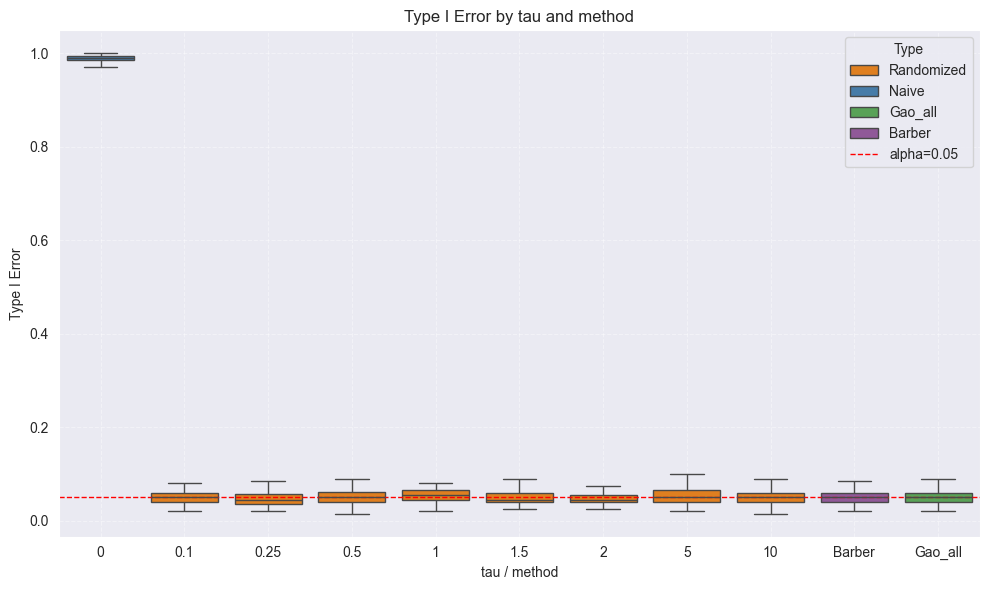

In [45]:
df_tau = type1.copy()
df_tau.loc[df_tau['Type'].str.lower() == 'naive', 'Tau'] = 0.0
df_tau['Group'] = df_tau['Tau'].astype(float).map(lambda x: f"{x:g}")
df_tau_plot = df_tau[['Group', 'Type', 'Type I Error']]

# --- FIX: make Type='Gao' for both, and distinct Group labels
df_gb_plot = pd.concat([
    type1_gao.assign(Group='Gao_all',      Type='Gao_all')[['Group','Type','Type I Error']],
    #type1_gao_c.assign(Group='Gao_clustered',Type='Gao_clustered')[['Group','Type','Type I Error']],
    type1_barber.assign(Group='Barber',              Type='Barber')[['Group','Type','Type I Error']]
], ignore_index=True)

df_all = pd.concat([df_tau_plot, df_gb_plot], ignore_index=True)

def _is_float(s):
    try:
        float(s); return True
    except:
        return False

tau_groups = sorted([g for g in df_all['Group'].unique() if _is_float(g)],
                    key=lambda s: float(s))

extra_groups = [g for g in [ 'Barber','Gao_all']
                if g in df_all['Group'].unique()]
order = tau_groups + extra_groups

hue_order = [h for h in ['Randomized','Naive','Gao_all','Barber'] if h in df_all['Type'].unique()]
palette = {
    'Randomized': '#FF7F00',
    'Naive':      '#377EB8',
    'Gao_all':       '#4DAF4A',
    'Barber':     '#984EA3',
}

df_all['Group'] = pd.Categorical(df_all['Group'], categories=order, ordered=True)
df_all['Type']  = pd.Categorical(df_all['Type'],  categories=hue_order, ordered=True)

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_all, x='Group', y='Type I Error',
    hue='Type', order=order, hue_order=hue_order,
    palette=palette, showfliers=False
)
plt.axhline(alpha, linestyle='--', linewidth=1, color='red', label=f'alpha={alpha}')
plt.xlabel('tau / method')
plt.title('Type I Error by tau and method')
plt.legend(title='Type')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('figs/invariant/type1_by_tau_method_boxplot.png', dpi=200)
plt.show()


In [17]:
df_gb_plot

,Group,Type,Type I Error
0,Gao (sigma_all),Gao,0.035
1,Gao (sigma_all),Gao,0.020
2,Gao (sigma_all),Gao,0.085
3,Gao (sigma_all),Gao,0.055
4,Gao (sigma_all),Gao,0.070
...,...,...,...
295,Barber,Barber,0.050
296,Barber,Barber,0.060
297,Barber,Barber,0.030
298,Barber,Barber,0.040


# Power vs Delta

In [2]:
dfg = pd.read_csv("/Users/judydw/Downloads/rejection_and_effect_gao.csv")
dfgc = pd.read_csv("/Users/judydw/Downloads/rejection_and_effect_gao_clustered.csv")
dfb = pd.read_csv("/Users/judydw/Downloads/rejection_and_effect_barber.csv")
dfr = pd.read_csv("/Users/judydw/Downloads/reject_es.csv")

Fitting tau=0.01
Fitting tau=0.05
Fitting tau=0.1


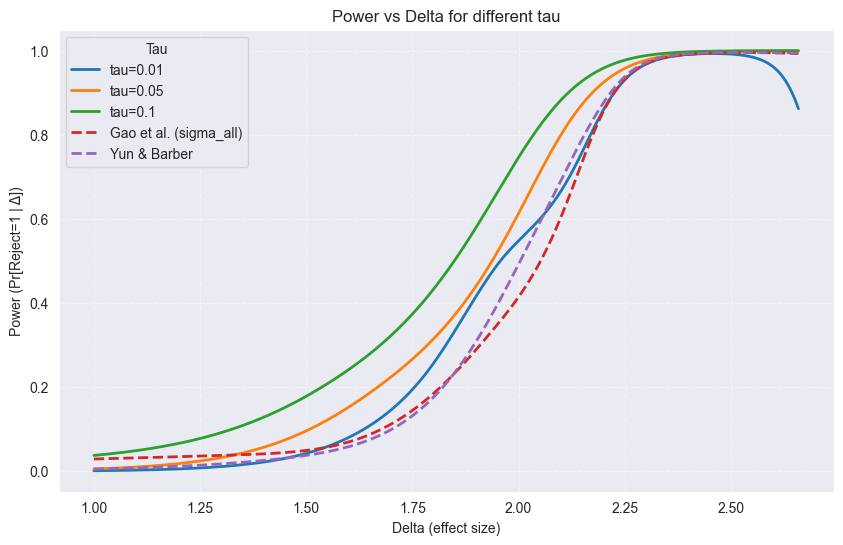

In [45]:
x_max = dfr.loc[dfr["tau"] == 0.01, "effect_size"].max()
plt.figure(figsize=(10, 6))

for tau, g in dfr.groupby("tau"):
    if tau in [0,0.5,0.75,1.0]:
        continue
    X = g[["effect_size"]].values
    y = g["reject"].values


    print(f"Fitting tau={tau}")
    gam = LogisticGAM(s(0), n_splines=10).fit(X, y)
    grid = np.linspace(1.0, x_max, 500)
    power_hat = gam.predict_mu(grid)
    plt.plot(grid, power_hat, lw=2, label=f"tau={tau}")
    
X_g = dfg["effect_size"].values
y_g = dfg["reject"].values
gam = LogisticGAM(s(0), n_splines=10).fit(X_g, y_g)
grid = np.linspace(1.0, x_max, 500)
power_hat = gam.predict_mu(grid)
plt.plot(grid, power_hat, lw=2,linestyle='--', label="Gao et al. (sigma_all)")

'''
X_gc = dfgc["effect_size"].values
y_gc = dfgc["reject"].values
gam = LogisticGAM(s(0), n_splines=4, constraints='monotonic_inc').fit(X_gc, y_gc)
grid = np.linspace(1.0, 3.0, 500)
power_hat = gam.predict_mu(grid)
plt.plot(grid, power_hat, lw=2,linestyle='--', label="Gao et al. (sigma_clustered)")
'''


X_b = dfb["effect_size"].values
y_b = dfb["reject"].values
gam = LogisticGAM(s(0),  n_splines=10).fit(X_b, y_b)
grid = np.linspace(1.0, x_max, 500)
power_hat = gam.predict_mu(grid)
plt.plot(grid, power_hat, lw=2,linestyle='--', label="Yun & Barber")
plt.xlabel("Delta (effect size)")
plt.ylabel("Power (Pr[Reject=1 | Δ])")
plt.title("Power vs Delta for different tau")
plt.legend(title="Tau")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

Binning & smoothing tau=0.01
Binning & smoothing tau=0.05
Binning & smoothing tau=0.1


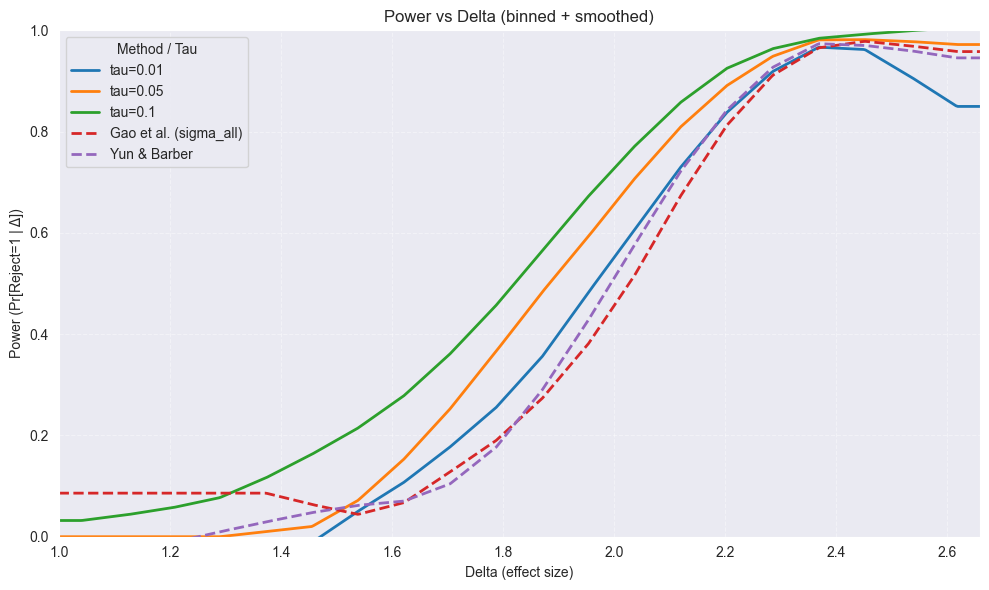

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.isotonic import IsotonicRegression

def binned_empirical_power(df, xcol="effect_size", ycol="reject",
                           x_min=1.0, x_max=3.0, n_bins=20, min_count=5):

    edges = np.linspace(x_min, x_max, n_bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    # assign bins
    idx = pd.cut(df[xcol].to_numpy(), bins=edges, include_lowest=True, right=True, labels=False)
    valid = ~pd.isna(idx)
    idx = idx[valid].astype(int)
    y = df.loc[valid, ycol].to_numpy()

    # aggregate
    counts = np.bincount(idx, minlength=n_bins)
    sums   = np.bincount(idx, weights=y, minlength=n_bins)
    with np.errstate(invalid="ignore", divide="ignore"):
        prop = sums / counts

    # filter sparse bins
    mask = (counts >= min_count) & np.isfinite(prop)
    return centers[mask], prop[mask], counts[mask]

def smooth_curve(x, y, method="lowess", grid=None, **kwargs):
    if grid is None:
        grid = x

    if method == "lowess":
        # returns values at x; we’ll interpolate to grid
        frac = kwargs.get("frac", 0.3)
        it   = kwargs.get("it", 1)
        yhat_at_x = lowess(y, x, frac=frac, it=it, return_sorted=False)
        # simple linear interpolation onto grid
        order = np.argsort(x)
        return np.interp(grid, x[order], yhat_at_x[order])


plt.figure(figsize=(10, 6))

x_min=1
x_max = dfr.loc[dfr["tau"] == 0.01, "effect_size"].max()
plot_grid = np.linspace(x_min, x_max, 500)
n_bins = 20
min_count = 1
smooth_method = "lowess"
for tau, g in dfr.groupby("tau"):
    if tau in [0, 0.5, 0.75, 1.0]:
        continue

    print(f"Binning & smoothing tau={tau}")
    bx, by, bc = binned_empirical_power(
        g, xcol="effect_size", ycol="reject",
        x_min=x_min, x_max=x_max, n_bins=n_bins, min_count=min_count
    )
    if len(bx) == 0:
        continue

    # smooth onto a common grid for clean overlays
    y_smooth = smooth_curve(bx, by, method=smooth_method, grid=plot_grid, frac=0.4)

    # optional: show binned points (size~count) + smoothed line
    #plt.scatter(bx, by, s=10 + 2*bc, alpha=0.6)
    plt.plot(plot_grid, y_smooth, lw=2, label=f"tau={tau}")

# --- Gao et al. (sigma_all) ---
bx, by, bc = binned_empirical_power(
    dfg, xcol="effect_size", ycol="reject",
    x_min=x_min, x_max=x_max, n_bins=n_bins, min_count=min_count
)
if len(bx) > 0:
    y_smooth = smooth_curve(bx, by, method=smooth_method, grid=plot_grid, frac=0.4)
    #plt.scatter(bx, by, s=10 + 2*bc, alpha=0.6)
    plt.plot(plot_grid, y_smooth, lw=2, linestyle="--", label="Gao et al. (sigma_all)")

# --- Yun & Barber ---
bx, by, bc = binned_empirical_power(
    dfb, xcol="effect_size", ycol="reject",
    x_min=x_min, x_max=x_max, n_bins=n_bins, min_count=min_count
)
if len(bx) > 0:
    y_smooth = smooth_curve(bx, by, method=smooth_method, grid=plot_grid, frac=0.4)
    #plt.scatter(bx, by, s=10 + 2*bc, alpha=0.6)
    plt.plot(plot_grid, y_smooth, lw=2, linestyle="--", label="Yun & Barber")

plt.xlabel("Delta (effect size)")
plt.ylabel("Power (Pr[Reject=1 | Δ])")
plt.title("Power vs Delta (binned + smoothed)")
plt.legend(title="Method / Tau")
plt.grid(True, linestyle="--", alpha=0.4)
plt.xlim(x_min, x_max)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


In [7]:

dfr = pd.read_csv("/Users/judydw/Downloads/reject_es-3.csv")

Fitting tau=0.01
Fitting tau=0.05
Fitting tau=0.1


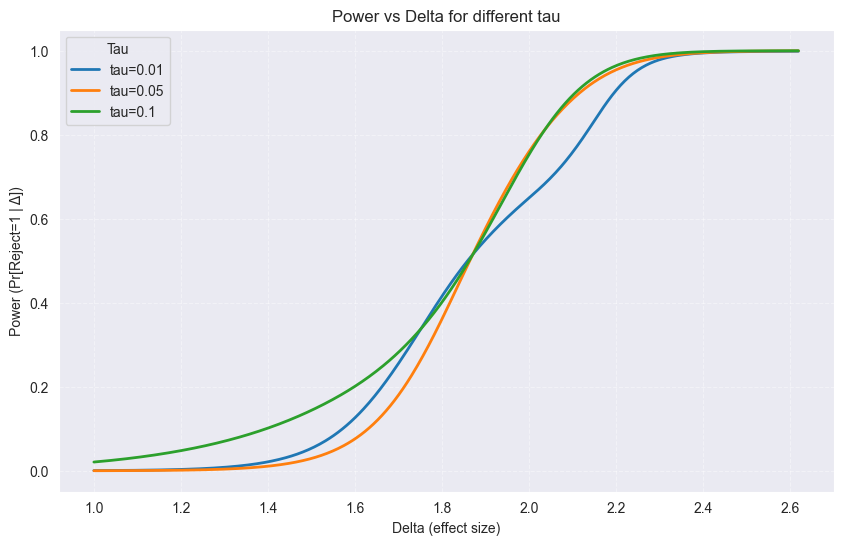

In [10]:
x_max = dfr.loc[dfr["tau"] == 0.01, "effect_size"].max()
plt.figure(figsize=(10, 6))

for tau, g in dfr.groupby("tau"):
    if tau in [0,0.5,0.75,1.0]:
        continue
    X = g[["effect_size"]].values
    y = g["reject"].values


    print(f"Fitting tau={tau}")
    gam = LogisticGAM(s(0), n_splines=10).fit(X, y)
    grid = np.linspace(1.0, x_max, 500)
    power_hat = gam.predict_mu(grid)
    plt.plot(grid, power_hat, lw=2, label=f"tau={tau}")
    
plt.xlabel("Delta (effect size)")
plt.ylabel("Power (Pr[Reject=1 | Δ])")
plt.title("Power vs Delta for different tau")
plt.legend(title="Tau")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

Binning & smoothing tau=0.01
Binning & smoothing tau=0.05
Binning & smoothing tau=0.1


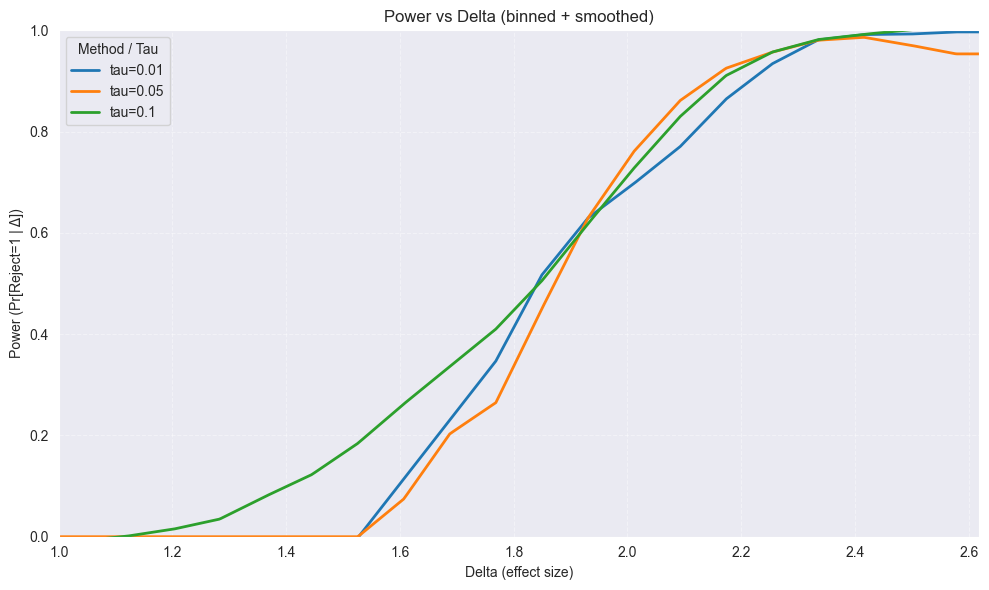

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.isotonic import IsotonicRegression

def binned_empirical_power(df, xcol="effect_size", ycol="reject",
                           x_min=1.0, x_max=3.0, n_bins=20, min_count=5):

    edges = np.linspace(x_min, x_max, n_bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    # assign bins
    idx = pd.cut(df[xcol].to_numpy(), bins=edges, include_lowest=True, right=True, labels=False)
    valid = ~pd.isna(idx)
    idx = idx[valid].astype(int)
    y = df.loc[valid, ycol].to_numpy()

    # aggregate
    counts = np.bincount(idx, minlength=n_bins)
    sums   = np.bincount(idx, weights=y, minlength=n_bins)
    with np.errstate(invalid="ignore", divide="ignore"):
        prop = sums / counts

    # filter sparse bins
    mask = (counts >= min_count) & np.isfinite(prop)
    return centers[mask], prop[mask], counts[mask]

def smooth_curve(x, y, method="lowess", grid=None, **kwargs):
    if grid is None:
        grid = x

    if method == "lowess":
        # returns values at x; we’ll interpolate to grid
        frac = kwargs.get("frac", 0.3)
        it   = kwargs.get("it", 1)
        yhat_at_x = lowess(y, x, frac=frac, it=it, return_sorted=False)
        # simple linear interpolation onto grid
        order = np.argsort(x)
        return np.interp(grid, x[order], yhat_at_x[order])


plt.figure(figsize=(10, 6))

x_min=1
x_max = dfr.loc[dfr["tau"] == 0.01, "effect_size"].max()
plot_grid = np.linspace(x_min, x_max, 500)
n_bins = 20
min_count = 1
smooth_method = "lowess"
for tau, g in dfr.groupby("tau"):
    if tau in [0, 0.5, 0.75, 1.0]:
        continue

    print(f"Binning & smoothing tau={tau}")
    bx, by, bc = binned_empirical_power(
        g, xcol="effect_size", ycol="reject",
        x_min=x_min, x_max=x_max, n_bins=n_bins, min_count=min_count
    )
    if len(bx) == 0:
        continue

    # smooth onto a common grid for clean overlays
    y_smooth = smooth_curve(bx, by, method=smooth_method, grid=plot_grid, frac=0.4)

    # optional: show binned points (size~count) + smoothed line
    #plt.scatter(bx, by, s=10 + 2*bc, alpha=0.6)
    plt.plot(plot_grid, y_smooth, lw=2, label=f"tau={tau}")

plt.xlabel("Delta (effect size)")
plt.ylabel("Power (Pr[Reject=1 | Δ])")
plt.title("Power vs Delta (binned + smoothed)")
plt.legend(title="Method / Tau")
plt.grid(True, linestyle="--", alpha=0.4)
plt.xlim(x_min, x_max)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()
